# Importamos las librerias a usar y cargamos el dataset procesado

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración estética
sns.set_theme(style="whitegrid")

# Cargamos el dataset limpio
df = pd.read_json("../data/processed/streaming_users_clean.json")

### 1. Variables Utilizadas y Propósito de PCA

El objetivo de PCA en este proyecto es reducir las dimensiones de comportamiento de los usuarios para identificar si existen "perfiles sintéticos" que sinteticen su actividad en la plataforma.

Se utilizan exclusivamente las variables numéricas continuas del dataset que definen la actividad y perfil del usuario:

age (Edad del usuario)

monthly_watch_time_mins (Tiempo de consumo mensual)

customer_support_tickets (Cantidad de reclamos a soporte)

In [16]:
# Seleccionamos las 3 variables numéricas para el análisis
variables = ["age", "monthly_watch_time_mins", "customer_support_tickets"]

# Separamos solo esas columnas en una matriz X
X = df[variables]

print("Variables seleccionadas:", variables)
print("Shape de X: ", X.shape)

Variables seleccionadas: ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
Shape de X:  (7633, 3)


### 2. Escalamiento Aplicado
PCA es extremadamente sensible a las escalas. Si dejamos los minutos mensuales (que van de 0 a casi 2700) mezclados con los tickets (que van de 0 a 5), la matemática de PCA va a pensar que los minutos son más importantes solo porque tienen números más grandes. Por eso se aplica StandardScaler para normalizar con media 0 y varianza 1.

In [29]:
# Calcular media y varianza antes del escalamiento
tabla_metricas = pd.DataFrame({
    'Mediana': df[variables].mean(),
    'Varianza': df[variables].var()
})

# Mostramos la tabla redondeada a 4 decimales
print("Media y Varianza antes del esclamiento:")
print(tabla_metricas.T.round(4))

Media y Varianza antes del esclamiento:
               age  monthly_watch_time_mins  customer_support_tickets
Mediana    33.5799                 795.1200                    0.7648
Varianza  133.9546              207889.9309                    0.8072


In [20]:
# Aplicamos el escalamiento estándar (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Variables escaladas correctamente. Media ~ 0 y Varianza ~ 1.")

Variables escaladas correctamente. Media ~ 0 y Varianza ~ 1.


In [28]:
# Calcular media y varianza después del escalamiento
tabla_metricas_escaladas = pd.DataFrame({
    'Media': X_scaled.mean(axis=0),
    'Varianza': X_scaled.var(axis=0)
}, index=variables)

print("Media y Varianza despues del escalamiento:")
print(tabla_metricas_escaladas.T.round(4))

Media y Varianza despues del escalamiento:
          age  monthly_watch_time_mins  customer_support_tickets
Media    -0.0                     -0.0                      -0.0
Varianza  1.0                      1.0                       1.0


# 3. Ejecución de PCA y Varianza Explicada
Corremos el algoritmo para generar los 3 componentes principales posibles (mismo número que variables de entrada) y analizamos cuánta información retiene cada uno.

In [26]:
# Inicializamos PCA para todos los componentes posibles
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Evaluamos la varianza
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Tabla resumen
resumen_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(3)],
    "Varianza explicada (%)": (varianza_explicada * 100).round(2),
    "Varianza acumulada (%)": (varianza_acumulada * 100).round(2)
})

print(resumen_pca.to_string(index=False))

Componente  Varianza explicada (%)  Varianza acumulada (%)
       PC1                   33.79                   33.79
       PC2                   33.12                   66.91
       PC3                   33.09                  100.00


### Varianza explicada por los componentes principales. 
Los tres componentes principales explican una proporción muy similar de la variabilidad total (33.79 %, 33.12 % y 33.09 %, respectivamente). Esto indica que la información del conjunto de datos se distribuye de manera equilibrada entre las tres dimensiones, sin que exista un componente claramente dominante. Al conservar los tres componentes se alcanza el 100 % de la varianza acumulada, lo que implica que la transformación mediante PCA preserva toda la información contenida en las variables originales. En este caso, el PCA resulta útil para interpretar la estructura de los datos, aunque no proporciona una reducción efectiva de la dimensionalidad, ya que es necesario mantener los tres componentes para conservar toda la información.

# 4. Visualizaciones

### Gráfico 1: Gráfico de Codo (Scree Plot)
Objetivo: Justificar matemáticamente con cuántos componentes nos deberíamos quedar si tuviéramos que reducir el dataset.

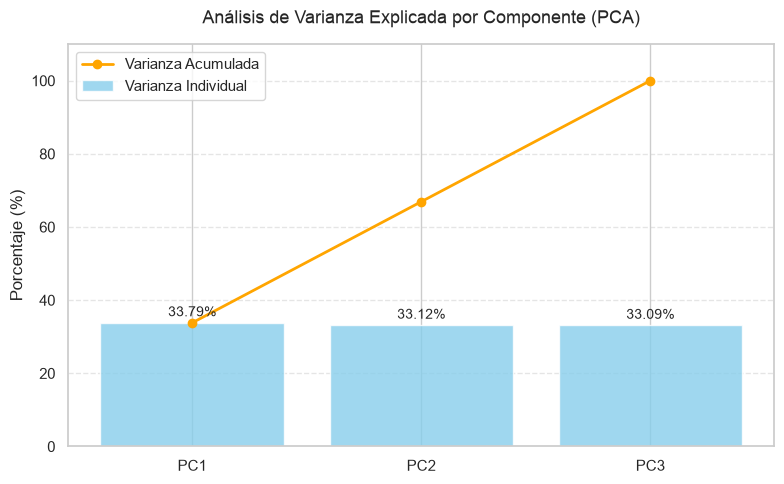

In [47]:
# Creamos la figura
plt.figure(figsize=(8, 5))

# 1. Dibujamos las barras para la varianza de cada PC
bars = plt.bar(resumen_pca["Componente"], resumen_pca["Varianza explicada (%)"], 
               color="skyblue", alpha=0.8, label="Varianza Individual")

# 2. Dibujamos la línea del acumulado
plt.plot(resumen_pca["Componente"], resumen_pca["Varianza acumulada (%)"], 
         color="orange", marker="o", linewidth=2, label="Varianza Acumulada")

# Agregamos los números arriba de las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f"{height}%", ha="center", va="bottom", fontsize=10)

# Configuraciones estéticas
plt.title("Análisis de Varianza Explicada por Componente (PCA)", fontsize=13, pad=15)
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

# Mostramos el gráfico
plt.tight_layout()
plt.show()

El gráfico de codo muestra cómo se distribuye la varianza entre los componentes principales. En este caso, como las variables seleccionadas no presentan una fuerte correlación lineal, la varianza se reparte de forma muy equilibrada: cada componente explica aproximadamente un 33,3% de la variabilidad total.

Al no observarse un "codo" o punto de inflexión, ningún componente destaca sobre los demás. Esto indica que no es posible reducir la dimensionalidad sin perder una parte importante de la información. De hecho, eliminar un solo componente implicaría descartar cerca de un tercio de la varianza, por lo que es necesario conservar los tres componentes para mantener el 100% de la información.

### Gráfico 2: Gráfico de Cargas (Loadings Plot).
Objetivo: Interpretar la composición matemática de las nuevas dimensiones estandarizadas.

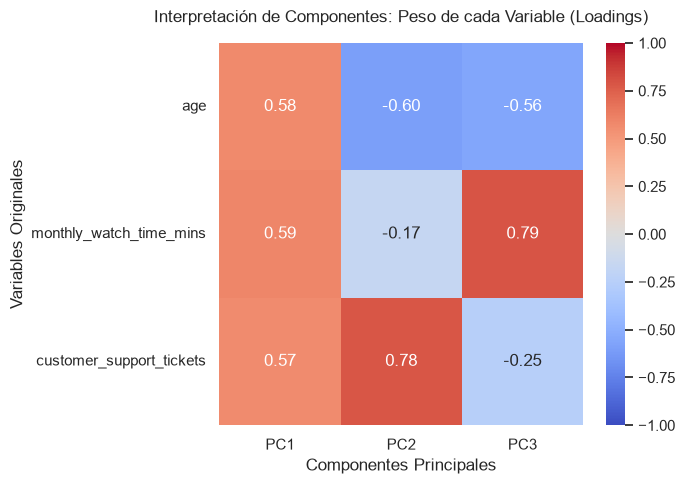

In [ ]:
# 1. Creamos un DataFrame con las cargas (componentes de PCA)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(3)], 
    index=['age', 'monthly_watch_time_mins', 'customer_support_tickets']
)

# 2. Armamos el Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, cbar=True)

# Estética del gráfico
plt.title('Interpretación de Componentes: Peso de cada Variable (Loadings)', fontsize=12, pad=15)
plt.ylabel('Variables Originales')
plt.xlabel('Componentes Principales')
plt.tight_layout()

plt.show()

In [50]:
# Imprimimos la matriz de cargas (Loadings) para entender los componentes textualmente
loadings_df = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=variables)
print("=== MATRIZ DE CARGAS (LOADINGS) ===")
print(loadings_df.round(2))

=== MATRIZ DE CARGAS (LOADINGS) ===
                           PC1   PC2   PC3
age                       0.58 -0.60 -0.56
monthly_watch_time_mins   0.59 -0.17  0.79
customer_support_tickets  0.57  0.78 -0.25


PC1 – Actividad General del Usuario. Este componente presenta cargas positivas y muy similares en las tres variables (0.57–0.59), indicando que resume un nivel general de actividad. Los usuarios con puntuaciones altas en PC1 tienden a ser de mayor edad, registrar más minutos de visualización y generar un mayor número de tickets de soporte.

PC2 – Interacción con Soporte en Usuarios Jóvenes. Este componente está dominado por la variable customer_support_tickets (0.78), con una relación inversa respecto a la edad (-0.60). Describe un contraste entre usuarios relativamente jóvenes que presentan una mayor interacción con el soporte técnico y usuarios de mayor edad con menor actividad de soporte.

PC3 – Consumo Intensivo. Este componente está principalmente asociado al tiempo mensual de visualización (0.79) y se relaciona negativamente con la edad (-0.56) y, en menor medida, con los tickets de soporte (-0.25). Puede interpretarse como un perfil de usuarios relativamente jóvenes con altos niveles de consumo de contenido y menor interacción con el soporte.

En conjunto, los componentes identifican patrones diferenciados en los datos: un eje de actividad general (PC1), un eje relacionado con el soporte técnico (PC2) y un eje asociado al consumo de contenido (PC3). La decisión de conservar los tres componentes debe complementarse con el análisis de la varianza explicada por cada uno.